In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
imdb = pd.read_csv('imdb_top_1000.csv')
imdb.head()

Saving imdb_top_1000.csv to imdb_top_1000.csv


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [4]:
imdb.dtypes

,0
Poster_Link,object
Series_Title,object
Released_Year,object
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object


In [5]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


converting to numeric values

In [6]:
imdb['Runtime'] = imdb['Runtime'].str.replace(' min', '').astype(float)
imdb['Gross'] = imdb['Gross'].replace({',': ''}, regex=True).astype(float)
imdb['IMDB_Rating'] = pd.to_numeric(imdb['IMDB_Rating'], errors='coerce')
imdb['Meta_score'] = pd.to_numeric(imdb['Meta_score'], errors='coerce')

In [7]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   float64
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(4), int64(1), object(11)
memory usage: 125.1+ KB


In [12]:

imdb['Certificate'] = imdb['Certificate'].fillna('Unknown')
imdb['Meta_score'] = imdb['Meta_score'].fillna(imdb['Meta_score'].median())
imdb['Gross'] = pd.to_numeric(imdb['Gross'], errors='coerce')
imdb['Gross'] = imdb['Gross'].fillna(0)
imdb['Released_Year'] = pd.to_numeric(imdb['Released_Year'], errors='coerce')

imdb.isnull().sum()






,0
Poster_Link,0
Series_Title,0
Released_Year,1
Certificate,0
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,0
Director,0


dropping row with missing release year

In [13]:
imdb.dropna(subset=['Released_Year'], inplace=True)

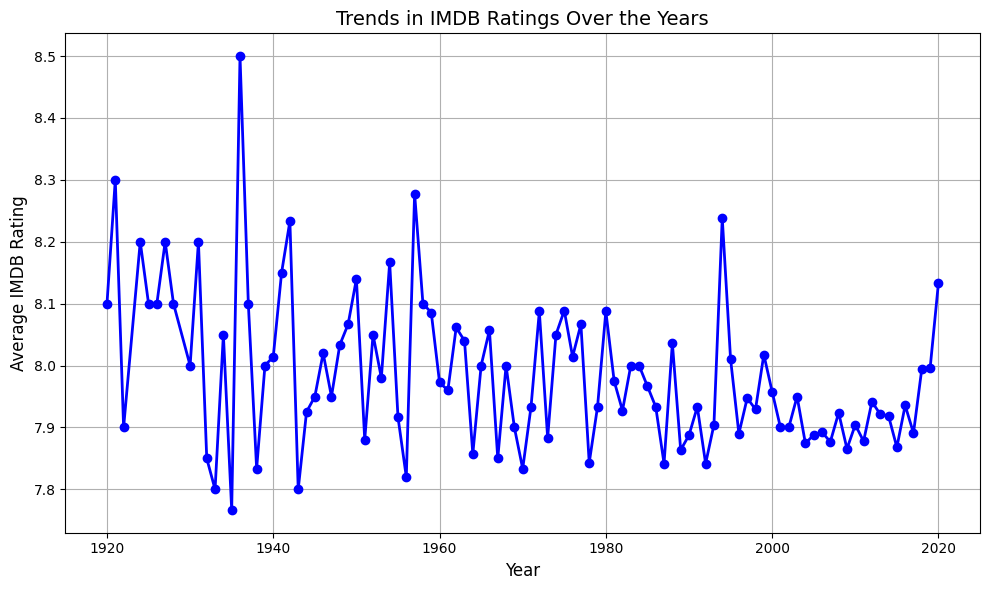

In [14]:
import matplotlib.pyplot as plt
yearly_ratings = imdb.groupby('Released_Year')['IMDB_Rating'].mean()
plt.figure(figsize=(10, 6))
plt.plot(yearly_ratings.index, yearly_ratings.values, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Trends in IMDB Ratings Over the Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average IMDB Rating', fontsize=12)
plt.grid(True)
plt.show()


In [15]:
imdb['Genre'].unique()

array(['Drama', 'Crime, Drama', 'Action, Crime, Drama',
       'Action, Adventure, Drama', 'Biography, Drama, History',
       'Action, Adventure, Sci-Fi', 'Drama, Romance', 'Western',
       'Action, Sci-Fi', 'Biography, Crime, Drama',
       'Action, Adventure, Fantasy', 'Comedy, Drama, Thriller',
       'Adventure, Drama, Sci-Fi', 'Animation, Adventure, Family',
       'Drama, War', 'Crime, Drama, Fantasy', 'Comedy, Drama, Romance',
       'Crime, Drama, Mystery', 'Crime, Drama, Thriller',
       'Action, Drama, Mystery', 'Drama, Family, Fantasy', 'Drama, Music',
       'Biography, Comedy, Drama', 'Drama, Mystery, Sci-Fi',
       'Biography, Drama, Music', 'Crime, Mystery, Thriller',
       'Animation, Adventure, Drama', 'Animation, Drama, War',
       'Adventure, Comedy, Sci-Fi', 'Horror, Mystery, Thriller',
       'Drama, Romance, War', 'Comedy, Drama, Family',
       'Animation, Drama, Fantasy', 'Action, Biography, Drama',
       'Animation, Action, Adventure', 'Drama, Western',


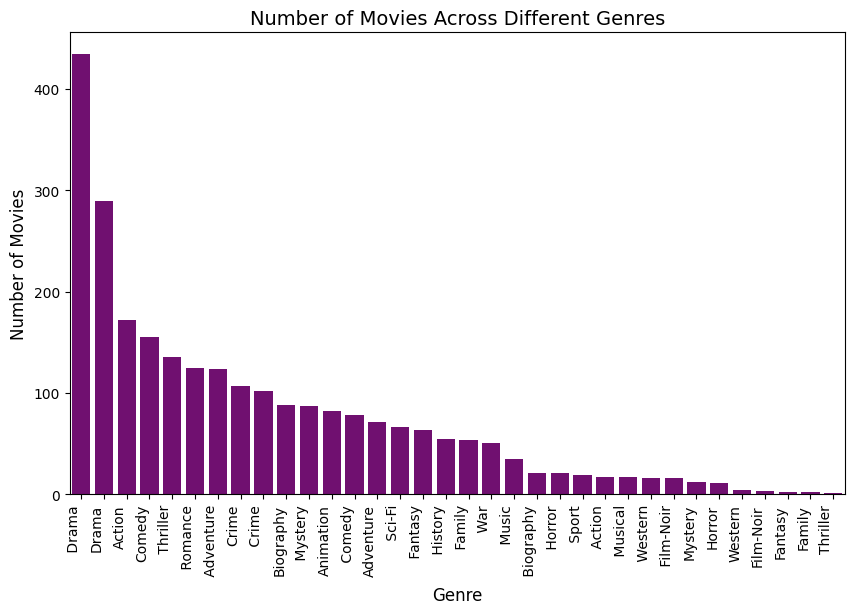

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
genres_split = imdb['Genre'].str.split(',', expand=True).stack()
genre_counts = genres_split.value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, color='purple')

plt.title('Number of Movies Across Different Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.show()


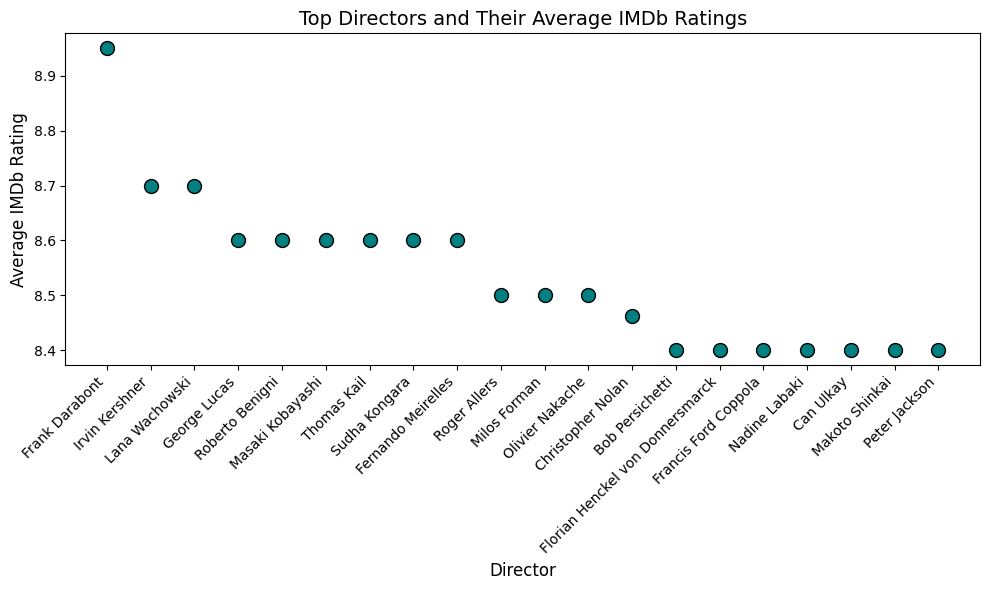

In [22]:
import matplotlib.pyplot as plt
director_ratings = imdb.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending=False)
top_directors = director_ratings.head(20)
plt.figure(figsize=(10, 6))
plt.scatter(top_directors.index, top_directors.values, color='teal', edgecolor='black', s=100)
plt.title('Top Directors and Their Average IMDb Ratings', fontsize=14)
plt.xlabel('Director', fontsize=12)
plt.ylabel('Average IMDb Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')rtfg
plt.show()


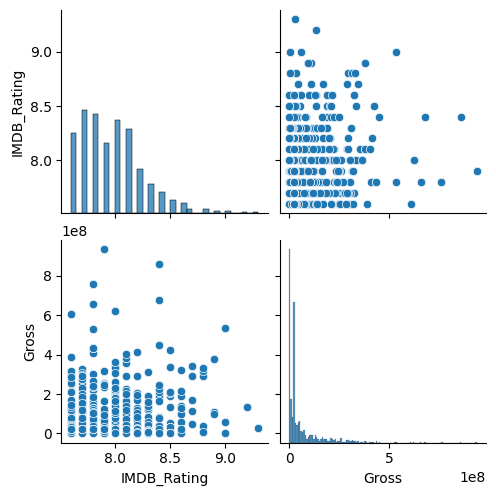

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

stars = imdb.melt(id_vars=['Series_Title', 'IMDB_Rating', 'Gross'],
                  value_vars=['Star1', 'Star2', 'Star3', 'Star4'],
                  var_name='Star_Type',
                  value_name='Star_Name')
sns.pairplot(stars[['Star_Name', 'IMDB_Rating', 'Gross']])
plt.show()



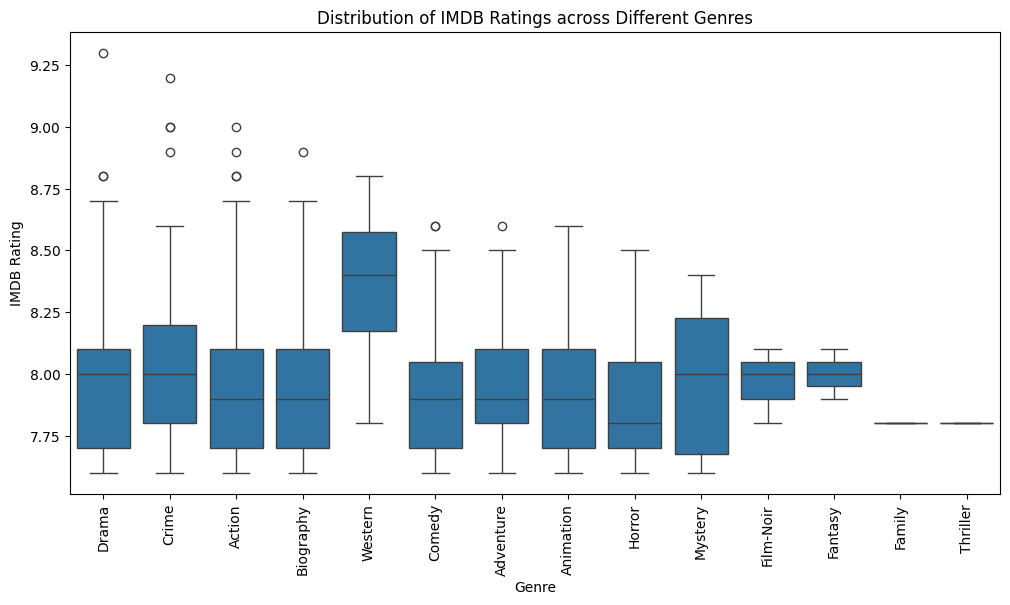

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

imdb['Primary_Genre'] = imdb['Genre'].str.split(',').str[0]
plt.figure(figsize=(12, 6))
sns.boxplot(x='Primary_Genre', y='IMDB_Rating', data=imdb)
plt.xticks(rotation=90)
plt.title('Distribution of IMDB Ratings across Different Genres')
plt.xlabel('Genre')
plt.ylabel('IMDB Rating')
plt.show()


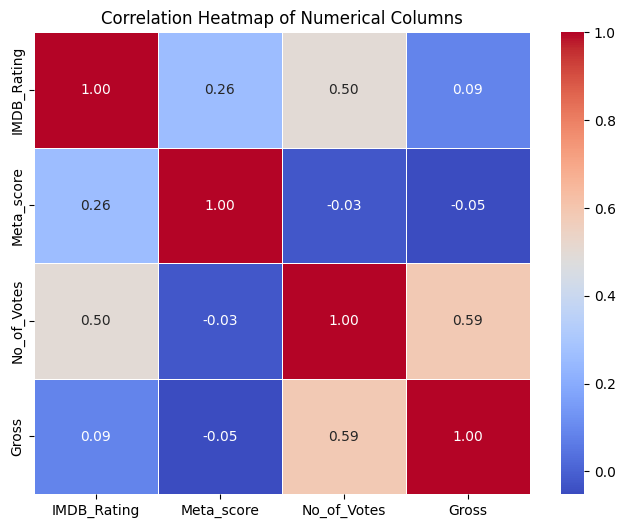

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
numerical_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
correlation_matrix = imdb[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()
